In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
import torch
import os
from pathlib import Path


In [16]:
def plot_similarity_scatter(eeg_dir, eeg_image_embed, subject_id=None, batch_size=100, 
                          n_strata=5, output_path=None, modality='EEG',
                          line_color='b', fill_color='skyblue', color='blue'):
    """
    Plot similarity scatter plot with stratified sampling where:
    - batch_size: TOTAL number of samples to draw
    - n_strata: Number of strata to divide the data into
    - output_path: Path to save the plot (optional)
    - eeg_image_embed: Pre-loaded image embeddings tensor
    - line_color: Color for regression line (default: 'b' for blue)
    - fill_color: Color for confidence interval (default: 'skyblue')
    """
    # Ensure image embeddings are on CPU
    eeg_image_embed = eeg_image_embed.cpu()

        
    # Calculate samples per stratum (distribute batch_size across n_strata)
    samples_per_stratum = batch_size // n_strata
    remainder = batch_size % n_strata
    
    # Stratify based on image embedding norms
    image_norms = torch.norm(eeg_image_embed, dim=1)
    strata_bounds = np.quantile(image_norms, np.linspace(0, 1, n_strata + 1))
    
    # Perform stratified sampling
    selected_indices = []
    for i in range(n_strata):
        # Get stratum indices
        mask = (image_norms >= strata_bounds[i]) & (image_norms < strata_bounds[i+1])
        stratum_indices = torch.where(mask)[0].numpy()
        
        if len(stratum_indices) == 0:
            continue
            
        # Adjust sample count for remainder
        n_samples = samples_per_stratum + (1 if i < remainder else 0)
        n_samples = min(n_samples, len(stratum_indices))
        
        # Random sample from stratum
        selected = np.random.choice(stratum_indices, n_samples, replace=False)
        selected_indices.extend(selected)
    
    selected_indices = np.array(selected_indices)
    actual_batch_size = len(selected_indices)

    # Process EEG data
    if subject_id is not None:
        # Single subject mode
        eeg_path = os.path.join(eeg_dir, subject_id, 'eeg_features_ATMS_test.pt')
        
        eeg_embed = torch.load(eeg_path)['features'].cpu()
        # if modality=='EEG' or modality=='MEG':
        #     eeg_embed = eeg_embed[::2]
        eeg_sim = cosine_similarity(eeg_embed[selected_indices])
        eeg_image_sim = cosine_similarity(eeg_image_embed[selected_indices])
        title = f'Subject {subject_id} ({actual_batch_size} samples from {n_strata} strata)'
    else:
        # Average across subjects
        subject_files = [os.path.join(eeg_dir, f, "eeg_features_ATMS_test.pt") for f in os.listdir(eeg_dir)]
        all_eeg_sim, all_eeg_image_sim = [], []
        
        for subj_file in subject_files:
            eeg_embed = torch.load(os.path.join(eeg_dir, subj_file))['features'].cpu()
            # if modality=='EEG' or modality=='MEG':
            #     eeg_embed = eeg_embed[::2]            
            all_eeg_sim.append(cosine_similarity(eeg_embed[selected_indices]))
            all_eeg_image_sim.append(cosine_similarity(eeg_image_embed[selected_indices]))
        
        eeg_sim = np.mean(all_eeg_sim, axis=0)
        eeg_image_sim = np.mean(all_eeg_image_sim, axis=0)

    # Extract upper triangle for plotting
    eeg_sim_flat = eeg_sim[np.triu_indices(actual_batch_size, k=1)]
    eeg_image_sim_flat = eeg_image_sim[np.triu_indices(actual_batch_size, k=1)]

    # Create plot
    plt.figure(figsize=(9, 9))
    sns.set(style="white", palette="muted",  font_scale=1.2)
    sns.set_context("notebook", rc={"lines.linewidth": 2.5})

    # Scatter plot
    plt.scatter(eeg_sim_flat, eeg_image_sim_flat, color=color, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(eeg_sim_flat, eeg_image_sim_flat)
    x_line = np.linspace(eeg_sim_flat.min(), eeg_sim_flat.max(), 100)
    y_line = slope * x_line + intercept

    # Confidence interval
    def get_confidence_interval(x, y, x_new, confidence=0.95):
        n = len(x)
        y_hat = slope * x_new + intercept
        s_err = np.sqrt(np.sum((y - (slope * x + intercept))**2 / (n - 2)))
        t_val = stats.t.ppf((1 + confidence) / 2, df=n-2)
        ci = t_val * s_err * np.sqrt(1/n + (x_new - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
        return y_hat - ci, y_hat + ci

    lower, upper = get_confidence_interval(eeg_sim_flat, eeg_image_sim_flat, x_line)

    # Plot regression and CI with custom colors
    plt.plot(x_line, y_line, f'{line_color}-', label=f'R={r_value:.2f}, p={p_value:.2e}')
    plt.fill_between(x_line, lower, upper, color=fill_color, alpha=0.4, label='95% Confidence Interval')

    plt.tick_params(axis='x', labelsize=30)  # 设置x轴刻度标签字体大小
    plt.tick_params(axis='y', labelsize=30)  # 设置x轴刻度标签字体大小

    # Formatting
    plt.xlabel(f'{modality} Feature Similarity', fontsize=40)
    plt.ylabel('Image Feature Similarity', fontsize=40)    
    
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    sns.despine(left=False, bottom=False)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=30)
    plt.grid(False)
    plt.tight_layout()

    # Handle output
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()




In [17]:
import torch

img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_features_test.pt")['img_features'].cpu()



/tmp/ipykernel_2740963/2913922031.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_feat

/tmp/ipykernel_2740963/1509306981.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eeg_embed = torch.load(eeg_path)['features'].cpu()


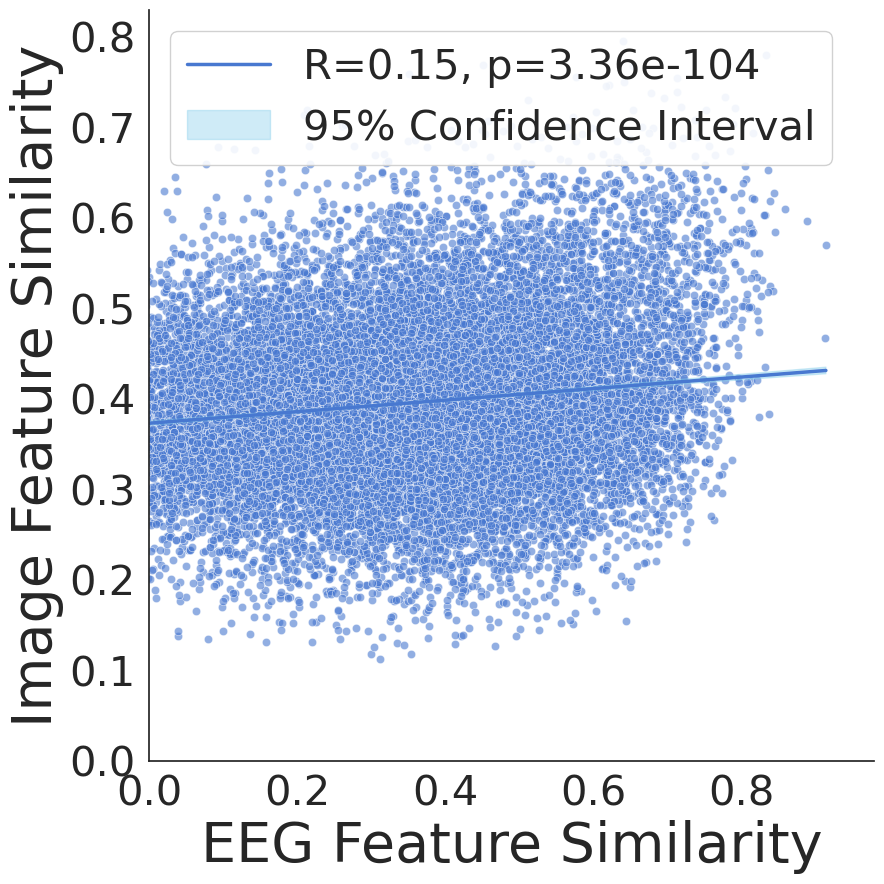

/tmp/ipykernel_2740963/1509306981.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eeg_embed = torch.load(os.path.join(eeg_dir, subj_file))['features'].cpu()
/tmp/ipyker

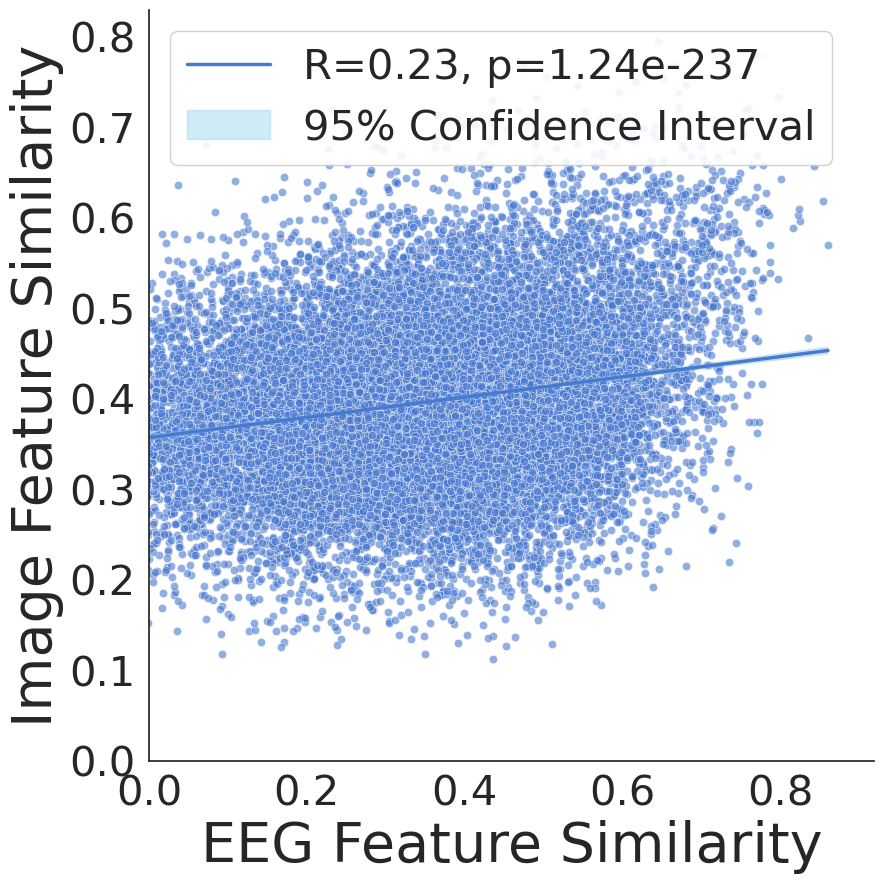

In [18]:
plot_similarity_scatter(
    eeg_dir='/mnt/dataset0/kyw/closed-loop/EEG_feature/sub_features',
    eeg_image_embed=img_embeds,
    subject_id='sub-01',
    batch_size=200,
    n_strata=5,
    output_path='/home/ldy/Closed_loop_optimizing/plots/Interactive_search/EEG_image_scatter_sub-01.png',
    modality='EEG',
    line_color='b', 
    fill_color='skyblue',  
    color='b'
)

plot_similarity_scatter(
    eeg_dir='/mnt/dataset0/kyw/closed-loop/EEG_feature/sub_features',
    eeg_image_embed=img_embeds,
    subject_id=None,
    batch_size=200,
    n_strata=5,
    output_path='/home/ldy/Closed_loop_optimizing/plots/Interactive_search/EEG_image_scatter_avg.png',
    modality='EEG',
    line_color='b', 
    fill_color='skyblue',  
    color='b'
)